# Two-Pass Photonic Cavity Analysis Workflow

This notebook provides a step-by-step implementation of the exact workflow from `run_analysis.py`. Each cell corresponds to a specific step in the analysis pipeline.

## 🔎 **Stage 1: Scout Analysis**
- **Step 1**: Setup and imports
- **Step 2**: Configuration classes and utilities
- **Step 3**: Configuration parameters
- **Step 4**: Scout simulation setup (create_q_scout_simulation)
- **Step 5**: Scout simulation execution
- **Step 6**: Q-factor analysis and resonance detection

## 🎯 **Stage 2: Lock-in Analysis**  
- **Step 7**: Lock-in simulation setup (create_simulation)
- **Step 8**: Lock-in simulation execution
- **Step 9**: Mode volume analysis
- **Step 10**: Polarization analysis
- **Step 11**: Near-field analysis
- **Step 12**: Far-field analysis
- **Step 13**: Collection efficiency analysis
- **Step 14**: Results summary

## Usage
Run each cell sequentially from top to bottom to execute the complete workflow.

---


## Step 1: Setup and Imports

Import all required modules and set up the analysis environment. This includes the exact same imports and setup as `run_analysis.py`.


In [1]:
# Import required modules (exact same as run_analysis.py)
from __future__ import annotations

import json
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Optional

import numpy as np

warnings.filterwarnings("ignore")

# Ensure repository root is on sys.path so we can import the top-level `modules` package
try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # In notebooks, __file__ is not defined; assume CWD is repo_root/notebooks
    REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.simulation_setup import SimulationSetup
from modules.simulation_runner import SimulationRunner
from modules.q_factor_analysis import analyze_q_factor
from modules.mode_volume_analysis import analyze_mode_volume
from modules.polarization_analysis import analyze_polarization
from modules.nearfield_analysis import analyze_nearfield
from modules.farfield_analysis import analyze_farfield
from modules.collection_efficiency_analysis import analyze_collection_efficiency

# Physical constant (shared with analysis modules)
C0 = 299_792_458.0  # Speed of light in vacuum (m/s)

print("✅ All modules imported successfully")
print("📁 Available analysis modules:")
print("  - Simulation setup and execution")
print("  - Q-factor analysis (ringdown)")
print("  - Mode volume analysis (Purcell factors)")
print("  - Polarization analysis (Stokes parameters)")
print("  - Near-field analysis (field confinement)")
print("  - Far-field analysis (radiation patterns)")
print("  - Collection efficiency analysis")


✅ All modules imported successfully
📁 Available analysis modules:
  - Simulation setup and execution
  - Q-factor analysis (ringdown)
  - Mode volume analysis (Purcell factors)
  - Polarization analysis (Stokes parameters)
  - Near-field analysis (field confinement)
  - Far-field analysis (radiation patterns)
  - Collection efficiency analysis


## Step 2: Configuration Classes and Utilities

Define the exact same configuration classes and utility functions as `run_analysis.py` for workflow management.


In [2]:
@dataclass
class StageOptions:
    """Configuration for an individual workflow stage."""

    name: str
    run_time_ps: float
    bandwidth_rel: float
    simulation_path: Path
    results_path: Path
    summary_path: Path
    task_name: str
    run_simulation: bool = False
    force_rerun: bool = False
    estimate_cost: bool = False


@dataclass
class WorkflowConfig:
    """Top-level configuration for the two-stage workflow."""

    thickness_um: float = 0.19
    initial_wavelength_um: float = 0.650
    stage: str = "all"
    n_bg: float = 1.0
    NA: float = 0.9
    resonance_wavelength_um: Optional[float] = None
    scout: Optional[StageOptions] = None
    lockin: Optional[StageOptions] = None


def format_thickness_tag(value: float) -> str:
    """Convert a thickness value into a compact string for filenames."""
    return f"{value:.3f}".rstrip("0").rstrip(".")


def ensure_parent_dir(path: Path) -> None:
    """Create the parent directory for *path* if needed."""
    parent = path.parent
    if parent and not parent.exists():
        parent.mkdir(parents=True, exist_ok=True)


def sanitize_for_json(obj: Any) -> Any:
    """Convert numpy/Path objects into JSON-friendly values."""
    if isinstance(obj, dict):
        return {k: sanitize_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize_for_json(v) for v in obj]
    if isinstance(obj, tuple):
        return [sanitize_for_json(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return sanitize_for_json(obj.tolist())
    if isinstance(obj, (np.floating, np.integer)):
        value = float(obj)
        if np.isnan(value) or np.isinf(value):
            return None
        return value
    if isinstance(obj, float):
        if np.isnan(obj) or np.isinf(obj):
            return None
        return obj
    return obj


def save_json(data: Dict[str, Any], path: Path) -> None:
    """Persist *data* as pretty-printed JSON."""
    ensure_parent_dir(path)
    with path.open("w") as fh:
        json.dump(sanitize_for_json(data), fh, indent=2)


def load_json(path: Path) -> Optional[Dict[str, Any]]:
    """Load JSON data from *path* if it exists."""
    if path is None or not path.exists():
        return None
    with path.open("r") as fh:
        return json.load(fh)


def build_default_workflow_config(
    thickness_um: float = 0.19,
    initial_wavelength_um: float = 0.650,
) -> WorkflowConfig:
    """Create a workflow configuration with sensible defaults."""
    tag = format_thickness_tag(thickness_um)
    scout = StageOptions(
        name="scout",
        run_time_ps=12.0,
        bandwidth_rel=0.12,
        simulation_path=(REPO_ROOT / f"data/simulations/simulation_scout_q_only_{tag}um.json"),
        results_path=(REPO_ROOT / f"data/results/results_scout_q_only_{tag}um.hdf5"),
        summary_path=(REPO_ROOT / f"data/summaries/scout_summary_{tag}um.json"),
        task_name=f"photonic_cavity_scout_{tag}um",
    )
    lockin = StageOptions(
        name="lockin",
        run_time_ps=8.0,
        bandwidth_rel=0.02,
        simulation_path=(REPO_ROOT / f"data/simulations/simulation_lockin_full_{tag}um.json"),
        results_path=(REPO_ROOT / f"data/results/results_lockin_full_{tag}um.hdf5"),
        summary_path=(REPO_ROOT / f"data/summaries/lockin_summary_{tag}um.json"),
        task_name=f"photonic_cavity_lockin_{tag}um",
    )
    return WorkflowConfig(
        thickness_um=thickness_um,
        initial_wavelength_um=initial_wavelength_um,
        scout=scout,
        lockin=lockin,
    )


def extract_float(value: Any) -> Optional[float]:
    """Safely convert *value* to float if possible."""
    if value is None:
        return None
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.atleast_1d(value)
        if arr.size == 0:
            return None
        value = arr.flat[0]
    try:
        out = float(value)
    except (TypeError, ValueError):
        return None
    if np.isnan(out) or np.isinf(out):
        return None
    return out

print("✅ Configuration classes and utility functions defined")
print("📋 Available configuration classes:")
print("  - StageOptions: Individual stage configuration")
print("  - WorkflowConfig: Top-level workflow configuration")
print("  - Utility functions: JSON handling, file management, data extraction")


✅ Configuration classes and utility functions defined
📋 Available configuration classes:
  - StageOptions: Individual stage configuration
  - WorkflowConfig: Top-level workflow configuration
  - Utility functions: JSON handling, file management, data extraction


## Step 3: Configuration Setup

Create the workflow configuration with default parameters (equivalent to parsing command line arguments in the script).


In [3]:
# Create workflow configuration (equivalent to config_from_args in the script)
# Using default parameters from run_analysis.py
thickness_um = 0.19  # Default thickness from the script
initial_wavelength_um = 0.650  # Default initial wavelength
NA = 0.6  # Default numerical aperture
n_bg = 1.0  # Default background index
stage = "all"  # Run both scout and lockin stages

# Check if results exist and run simulations if needed
config_temp = build_default_workflow_config(
    thickness_um=thickness_um,
    initial_wavelength_um=initial_wavelength_um,
)

# Check if scout results exist
scout_results_exist = config_temp.scout.results_path.exists()
lockin_results_exist = config_temp.lockin.results_path.exists()

# Run simulations if results don't exist
run_simulations = not (scout_results_exist and lockin_results_exist)
force_rerun = False      # Don't force rerun if results exist
estimate_cost = run_simulations  # Always estimate cost when running simulations

print(f"🔍 Checking for existing results:")
print(f"  Scout results exist: {scout_results_exist}")
print(f"  Lock-in results exist: {lockin_results_exist}")
print(f"  Will run simulations: {run_simulations}")
print(f"  Will estimate cost: {estimate_cost}")

# Create the configuration
config = build_default_workflow_config(
    thickness_um=thickness_um,
    initial_wavelength_um=initial_wavelength_um,
)

# Update configuration with parameters
config.stage = stage
config.n_bg = n_bg
config.NA = NA
config.resonance_wavelength_um = None  # Will be set after scout stage

# Set simulation execution flags
if run_simulations:
    config.scout.run_simulation = True
    config.scout.estimate_cost = estimate_cost
    config.lockin.run_simulation = True
    config.lockin.estimate_cost = estimate_cost

if force_rerun:
    config.scout.force_rerun = True
    config.lockin.force_rerun = True

print("🔧 Configuration created:")
print(f"  Thickness: {config.thickness_um} µm")
print(f"  Initial wavelength: {config.initial_wavelength_um} µm")
print(f"  Numerical aperture: {config.NA}")
print(f"  Background index: {config.n_bg}")
print(f"  Stage: {config.stage}")
print(f"  Run simulations: {run_simulations}")
print(f"  Force rerun: {force_rerun}")
print(f"  Estimate cost: {estimate_cost}")

print(f"\n📁 File paths:")
print(f"  Scout simulation: {config.scout.simulation_path}")
print(f"  Scout results: {config.scout.results_path}")
print(f"  Scout summary: {config.scout.summary_path}")
print(f"  Lock-in simulation: {config.lockin.simulation_path}")
print(f"  Lock-in results: {config.lockin.results_path}")
print(f"  Lock-in summary: {config.lockin.summary_path}")


🔍 Checking for existing results:
  Scout results exist: True
  Lock-in results exist: True
  Will run simulations: False
  Will estimate cost: False
🔧 Configuration created:
  Thickness: 0.19 µm
  Initial wavelength: 0.65 µm
  Numerical aperture: 0.6
  Background index: 1.0
  Stage: all
  Run simulations: False
  Force rerun: False
  Estimate cost: False

📁 File paths:
  Scout simulation: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/simulations/simulation_scout_q_only_0.19um.json
  Scout results: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/results/results_scout_q_only_0.19um.hdf5
  Scout summary: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/summaries/scout_summary_0.19um.json
  Lock-in simulation: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/simulations/simulation_lockin_full_0.19um.json
  Lock-in results: /Users/sandrobuzzi/Documents/

## Step 4: Scout Stage - Create Directories and Setup

Start the scout stage by creating necessary directories and setting up the simulation environment. This corresponds to the beginning of `run_scout_stage()` in the script.


In [4]:
# Start scout stage - create directories and setup
print("=" * 80)
print("🔎 SCOUT STAGE — broadband resonance search")
print("=" * 80)

stage = config.scout

# Create parent directories for all scout files
ensure_parent_dir(stage.simulation_path)
ensure_parent_dir(stage.results_path)
ensure_parent_dir(stage.summary_path)

print(f"✓ Ensured directories for scout stage")
print(f"  Simulation file: {stage.simulation_path}")
print(f"  Results file: {stage.results_path}")
print(f"  Summary file: {stage.summary_path}")

print(f"✓ Scout stage configuration:")
print(f"  Thickness: {config.thickness_um} µm")
print(f"  Wavelength: {config.initial_wavelength_um} µm")
print(f"  Bandwidth: {stage.bandwidth_rel*100:.1f}%")
print(f"  Run time: {stage.run_time_ps} ps")


🔎 SCOUT STAGE — broadband resonance search
✓ Ensured directories for scout stage
  Simulation file: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/simulations/simulation_scout_q_only_0.19um.json
  Results file: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/results/results_scout_q_only_0.19um.hdf5
  Summary file: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/summaries/scout_summary_0.19um.json
✓ Scout stage configuration:
  Thickness: 0.19 µm
  Wavelength: 0.65 µm
  Bandwidth: 12.0%
  Run time: 12.0 ps


## Step 5: Scout Stage - Create and Save Simulation

Create the scout simulation using `create_q_scout_simulation()` and save it to file. This corresponds to the simulation creation and saving in `run_scout_stage()`.


In [5]:
# Create scout simulation and save it (only if running simulations)
if run_simulations:
    # Create SimulationSetup for scout stage
    setup = SimulationSetup(
        thickness_um=config.thickness_um,
        wavelength_um=config.initial_wavelength_um,
        source_bandwidth_rel=stage.bandwidth_rel,
    )
    
    simulation = setup.create_q_scout_simulation(run_time_ps=stage.run_time_ps)
    setup.save_simulation(simulation, str(stage.simulation_path))

    print(f"✓ Created scout simulation")
    print(f"  Run time: {stage.run_time_ps} ps")
    print(f"  Bandwidth: {stage.bandwidth_rel*100:.1f}%")
    print(f"  Simulation saved to: {stage.simulation_path}")

    # Display simulation info
    print(f"\n📊 Simulation details:")
    print(f"  Structures: {len(simulation.structures)}")
    print(f"  Monitors: {len(simulation.monitors)}")
    print(f"  Run time: {simulation.run_time} ps")
    print(f"  Grid: {simulation.grid_spec}")
    print(f"  Boundaries: {simulation.boundary_spec}")
else:
    print("⏭️  Skipping simulation creation (using existing results)")


⏭️  Skipping simulation creation (using existing results)


## Step 6: Scout Stage - Run Simulation

Execute the scout simulation using `SimulationRunner`. This corresponds to the simulation execution part of `run_scout_stage()`.


In [6]:
# Run scout simulation (only if running simulations)
if run_simulations:
    print("🎯 RUNNING SCOUT SIMULATION")
    runner = SimulationRunner(task_name=stage.task_name)
    runner.run_simulation(
        simulation=simulation,
        results_path=str(stage.results_path),
        force_rerun=stage.force_rerun,
        estimate_cost_first=stage.estimate_cost,
        expected_monitors=["probe"],
    )
    print("✓ Scout simulation completed")
else:
    if stage.results_path.exists():
        print(f"✓ Using existing scout results at {stage.results_path}")
    else:
        raise FileNotFoundError(
            f"Scout results file not found: {stage.results_path}. Run the scout "
            "simulation (e.g. with modules/simulation_runner.py) before continuing."
        )

print(f"📁 Scout results available at: {stage.results_path}")
print(f"🎯 Ready for Q-factor analysis")


✓ Using existing scout results at /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/results/results_scout_q_only_0.19um.hdf5
📁 Scout results available at: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/results/results_scout_q_only_0.19um.hdf5
🎯 Ready for Q-factor analysis


## Step 7: Scout Stage - Q-Factor Analysis and Resonance Detection

Analyze the scout simulation results to extract quality factors and detect the resonance frequency. This corresponds to the Q-factor analysis part of `run_scout_stage()`.


🔬 Q-FACTOR ANALYSIS
🔬 Q-FACTOR RINGDOWN ANALYSIS (FFT-based)
✓ Extracted signal data
  - Time points: 86378
  - Duration: 12.00 ps
  - Time step: 0.000 ps
✓ Prepared analysis segment
  - Tail start: peak+guard (index 230)
  - Tail duration: 11.968 ps
  - Tail points: 86148
✓ Frequency estimation comparison:
  - FFT estimate: 458.385197 THz
  - Wavelength guess: 461.219166 THz
  - Difference: 2.833969 THz
  - Using: 458.385197 THz (FFT-based)
✓ Extracted initial seeds
  - Frequency seed: 458.405956 THz
  - Decay rate seed: 1.077e+11 1/s
  - Primary frequency: 458.385197 THz
✓ Built search grids (improved span)
  - Frequency grid: 121 points
  - Decay rate grid: 81 points
  - Grid span: ±5.0%
✓ Single mode fit complete
  - Frequency: 458.385197 THz
  - Decay time: 9.257 ps
  - Q-factor: 13,331
  - Residual: 17.18%
  - Coverage: 1.29 e-folds
✓ Multi-mode analysis complete
  - Effective modes: 1
  - Grid residual: 17.18%
✓ Variable projection refinement complete
  - Mode 1: f=458.405960 TH

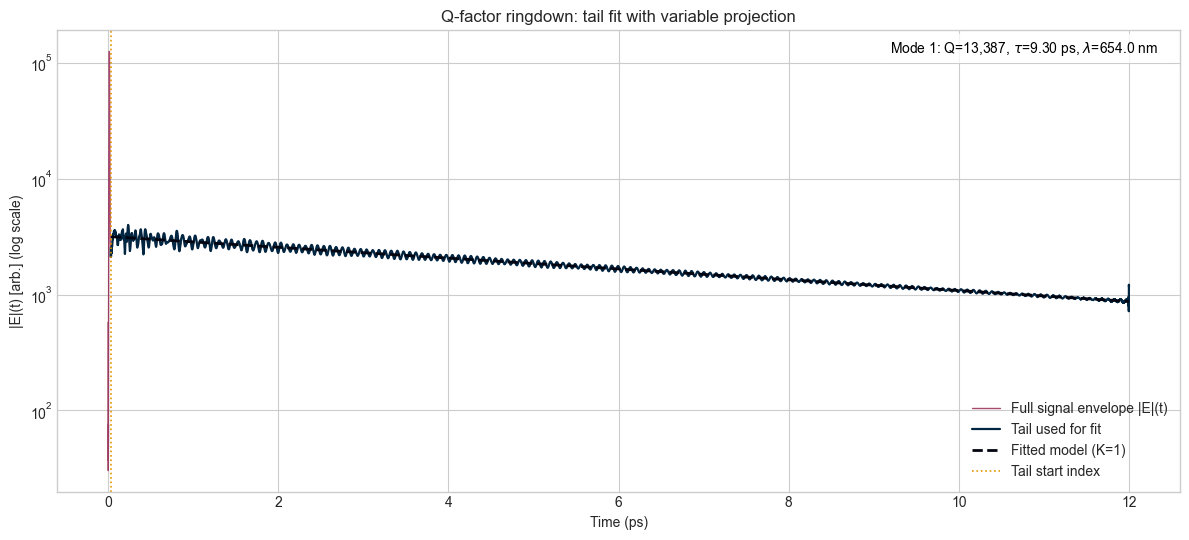

✓ Ringdown analysis plot saved to /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/figures/q_factor_analysis.png
✓ Q-factor analysis completed
  Resonance frequency: 458.405960 THz
  Resonance wavelength: 0.653989 µm
  Quality factor: 13,387
  Decay time: 9.296 ps
✓ Scout summary written to /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/summaries/scout_summary_0.19um.json
🎯 Resonance detected at 0.653989 µm
📊 Quality factor Q = 13,387


In [7]:
# Q-factor analysis and resonance detection
print("🔬 Q-FACTOR ANALYSIS")
print("=" * 50)

q_results = analyze_q_factor(
    data_path=str(stage.results_path),
    wavelength_um=config.initial_wavelength_um,
    save_results=False,
)

# Extract key results
freq_hz = extract_float(q_results.get("frequencies_hz"))
q_factor = extract_float(q_results.get("q_factors"))
tau_ps = None
if "decay_times_s" in q_results:
    tau_ps = extract_float(np.array(q_results["decay_times_s"]) * 1e12)

if freq_hz is None or q_factor is None:
    raise RuntimeError("Q-factor analysis did not return valid frequency/Q values.")

# Calculate resonance wavelength
resonance_wavelength_um = C0 / freq_hz * 1e6

print(f"✓ Q-factor analysis completed")
print(f"  Resonance frequency: {freq_hz / 1e12:.6f} THz")
print(f"  Resonance wavelength: {resonance_wavelength_um:.6f} µm")
print(f"  Quality factor: {q_factor:,.0f}")
if tau_ps is not None:
    print(f"  Decay time: {tau_ps:.3f} ps")

# Create scout summary
scout_summary = {
    "stage": stage.name,
    "simulation_file": str(stage.simulation_path),
    "results_file": str(stage.results_path),
    "run_time_ps": stage.run_time_ps,
    "bandwidth_rel": stage.bandwidth_rel,
    "resonance_frequency_thz": freq_hz / 1e12,
    "resonance_wavelength_um": resonance_wavelength_um,
    "q_factor": q_factor,
    "decay_time_ps": tau_ps,
    "num_modes": int(q_results.get("num_modes", 1)),
}

# Save scout summary
save_json(scout_summary, stage.summary_path)

print(f"✓ Scout summary written to {stage.summary_path}")
print(f"🎯 Resonance detected at {resonance_wavelength_um:.6f} µm")
print(f"📊 Quality factor Q = {q_factor:,.0f}")

# Store results for lock-in stage
scout_output = {"summary": scout_summary, "raw": q_results}
config.resonance_wavelength_um = resonance_wavelength_um


## Step 8: Lock-in Stage - Create Directories and Setup

Start the lock-in stage by creating necessary directories and setting up the simulation environment at the detected resonance wavelength. This corresponds to the beginning of `run_lockin_stage()` in the script.


In [8]:
# Start lock-in stage - create directories and setup
print("=" * 80)
print("🎯 LOCK-IN STAGE — narrowband analysis")
print("=" * 80)

stage = config.lockin

# Create parent directories for all lock-in files
ensure_parent_dir(stage.simulation_path)
ensure_parent_dir(stage.results_path)
ensure_parent_dir(stage.summary_path)

print(f"✓ Created directories for lock-in stage")
print(f"  Simulation file: {stage.simulation_path}")
print(f"  Results file: {stage.results_path}")
print(f"  Summary file: {stage.summary_path}")

# Get lock-in wavelength from scout results
lockin_wavelength = config.resonance_wavelength_um or scout_summary.get("resonance_wavelength_um")
if lockin_wavelength is None:
    raise RuntimeError(
        "Resonance wavelength unavailable. Run the scout stage first or provide "
        "--resonance-wavelength-um."
    )

lockin_frequency_thz = C0 / (lockin_wavelength * 1e-6) / 1e12
print(f"Using lock-in wavelength {lockin_wavelength:.6f} µm ({lockin_frequency_thz:.6f} THz)")

# Create SimulationSetup for lock-in stage
setup = SimulationSetup(
    thickness_um=config.thickness_um,
    wavelength_um=lockin_wavelength,
    source_bandwidth_rel=stage.bandwidth_rel,
)

print(f"✓ Created SimulationSetup for lock-in stage")
print(f"  Thickness: {config.thickness_um} µm")
print(f"  Wavelength: {lockin_wavelength:.6f} µm")
print(f"  Bandwidth: {stage.bandwidth_rel*100:.1f}%")
print(f"  Run time: {stage.run_time_ps} ps")


🎯 LOCK-IN STAGE — narrowband analysis
✓ Created directories for lock-in stage
  Simulation file: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/simulations/simulation_lockin_full_0.19um.json
  Results file: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/results/results_lockin_full_0.19um.hdf5
  Summary file: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/summaries/lockin_summary_0.19um.json
Using lock-in wavelength 0.653989 µm (458.405960 THz)
🔧 SETTING UP GEOMETRY PARAMETERS
✓ Geometry parameters loaded
  - Cavity thickness: 0.19 µm
  - Wavelength: 0.6539890052265658 µm
  - Optimized padding: x=[-5.0, -5.0], y=[2.0, 2.0], z=[2.0, 2.0]

🔬 Creating diamond medium with full Sellmeier dispersion...
  - Using full Sellmeier dispersion model
  - Coefficients: B1=0.3306, C1=0.175²; B2=4.3356, C2=0.106²
  - Reference n(λ=0.654 µm) = 2.410118
  - Full frequency-dependent dispersion enabl

## Step 9: Lock-in Stage - Create and Save Simulation

Create the lock-in simulation using `create_simulation()` and save it to file. This corresponds to the simulation creation and saving in `run_lockin_stage()`.


In [9]:
# Create lock-in simulation and save it
simulation = setup.create_simulation(run_time_ps=stage.run_time_ps)
setup.save_simulation(simulation, str(stage.simulation_path))

print(f"✓ Created lock-in simulation")
print(f"  Run time: {stage.run_time_ps} ps")
print(f"  Bandwidth: {stage.bandwidth_rel*100:.1f}%")
print(f"  Simulation saved to: {stage.simulation_path}")

# Display simulation info
print(f"\n📊 Lock-in simulation details:")
print(f"  Structures: {len(simulation.structures)}")
print(f"  Monitors: {len(simulation.monitors)}")
print(f"  Run time: {simulation.run_time} ps")
print(f"  Grid: {simulation.grid_spec}")
print(f"  Boundaries: {simulation.boundary_spec}")

# List all monitors for verification
print(f"\n📡 Monitors created:")
for i, monitor in enumerate(simulation.monitors, 1):
    print(f"  {i}. {monitor.name}: {type(monitor).__name__}")



🚀 Creating complete simulation...

📐 Extracting geometry from GDS files...
  - Using cell: TOP
  - Original bbox: x[-15.675, 15.675], y[-0.150, 0.150]
  - Geometry bbox: x[-15.675, 15.675], y[-0.150, 0.150]
  - Simulation domain: left=-10.675, right=10.675, bottom=-2.150, top=2.150
  - X truncation: 31.350 → 21.350 µm (reduced by 10.000 µm)
  - Simulation size: (21.350, 4.300, 4.190) µm
  - Simulation center: (0.000, 0.000, 0.000) µm

🏗️  Creating core structure...
  - Core rectangle created with 4 vertices
  - Thickness: 0.19 µm

🕳️  Creating hole structures...
  - Using holes cell: TOP
  - Imported 100 hole polygon(s)
  - Created 1 hole structure(s)
  - Thickness: 0.19 µm

📡 Creating sources and monitors...
  - Source: Point dipole at (0.000, 0.000, 0.0)
  - Frequency: 458.406 THz
  - Bandwidth: 9.17 THz
  - Created 3 basic monitors

🌐 Creating improved far-field monitors...
  - Positioning monitors at z = 1.5 µm
  - Monitor size: 8.0 µm
  - Created 3 improved far-field monitors
✓ C

## Step 10: Lock-in Stage - Run Simulation

Execute the lock-in simulation using `SimulationRunner` with all required monitors for detailed analysis. This corresponds to the simulation execution part of `run_lockin_stage()`.


In [10]:
# Run lock-in simulation
if run_simulations:
    print("🎯 RUNNING LOCK-IN SIMULATION")
    runner = SimulationRunner(task_name=stage.task_name)
    runner.run_simulation(
        simulation=simulation,
        results_path=str(stage.results_path),
        force_rerun=stage.force_rerun,
        estimate_cost_first=stage.estimate_cost,
        expected_monitors=[
            "probe",
            "flux",
            "field_near",
            "farfield_cartesian",
            "farfield_kspace",
            "farfield_angles",
            "fld_3d_box",
        ],
    )
    print("✓ Lock-in simulation completed")
else:
    if stage.results_path.exists():
        print(f"✓ Using existing lock-in results at {stage.results_path}")
    else:
        raise FileNotFoundError(
            f"Lock-in results file not found: {stage.results_path}. Run the lock-in "
            "simulation before launching the analyses."
        )

print(f"📁 Lock-in results available at: {stage.results_path}")
print(f"🎯 Ready for detailed analysis (mode volume, polarization, near-field, far-field, collection efficiency)")


✓ Using existing lock-in results at /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/results/results_lockin_full_0.19um.hdf5
📁 Lock-in results available at: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/results/results_lockin_full_0.19um.hdf5
🎯 Ready for detailed analysis (mode volume, polarization, near-field, far-field, collection efficiency)


## Step 11: Mode Volume Analysis

Analyze the effective mode volume and calculate Purcell factors for quantum applications. This corresponds to the mode volume analysis part of `run_lockin_stage()`.


In [11]:
# Mode volume analysis
print("🔬 MODE VOLUME ANALYSIS")
print("=" * 50)

# Get Q-factor from scout results for Purcell factor calculation
q_for_lockin = extract_float(scout_summary.get("q_factor"))
if q_for_lockin is None:
    print("⚠️  Q-factor unavailable; Purcell metrics may be limited.")

try:
    mv_results = analyze_mode_volume(
        data_path=str(stage.results_path),
        thickness_um=config.thickness_um,
        wavelength_um=lockin_wavelength,
        Q=q_for_lockin,
        save_results=True,
        create_plots=True,
    )
    
    print("✓ Mode volume analysis completed")
    print(f"  Effective mode volume: {mv_results.get('effective_mode_volume_um3', 'N/A')} µm³")
    if mv_results.get('purcell_factor') is not None:
        print(f"  Purcell factor: {mv_results.get('purcell_factor', 'N/A')}")
    
    # Store results for summary
    mode_volume_um3 = extract_float(mv_results.get("effective_mode_volume_um3"))
    purcell_factor = extract_float(mv_results.get("purcell_factor"))
    
except Exception as exc:
    print(f"❌ Mode volume analysis failed: {exc}")
    mv_results = {"error": str(exc)}
    mode_volume_um3 = None
    purcell_factor = None


🔬 MODE VOLUME ANALYSIS
  - Using Sellmeier equation for diamond: n(λ=0.654 µm) = 2.410118
🔬 MODE VOLUME ANALYSIS
✓ Loaded 3D field data
  - Field shape: (68, 102, 400)
  - X range: -3.007 to 3.007 µm
  - Y range: -1.534 to 1.534 µm
  - Z range: -1.009 to 1.009 µm

🔧 Creating permittivity map from GDS geometry...
❌ Mode volume analysis failed: Cavity GDS not found: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/gds/Cavity.gds


## Step 12: Polarization Analysis

Analyze far-field polarization properties including Stokes parameters, degree of polarization, and collection efficiency. This corresponds to the polarization analysis part of `run_lockin_stage()`.


🔄 POLARIZATION ANALYSIS
🔬 FAR-FIELD POLARIZATION ANALYSIS
✓ Using angle monitor: farfield_angles
✓ Extracted far-field data
  - Field shape: (100, 200)
  - Theta range: 0.0° to 90.0°
  - Phi range: 0.0° to 360.0°
✓ Calculated NA cone
  - NA: 0.6
  - Background index: 1.0
  - Theta max: 36.9°
✓ Calculated polarization metrics
  - DoLP: 0.072
  - DoCP: 0.001
  - DoP: 0.072
  - Psi: 0.4°
  - Chi: -0.0°
✓ Collection efficiency: 49.84%
✓ Polarization state: mostly unpolarized

📊 Creating theta-phi heatmaps...


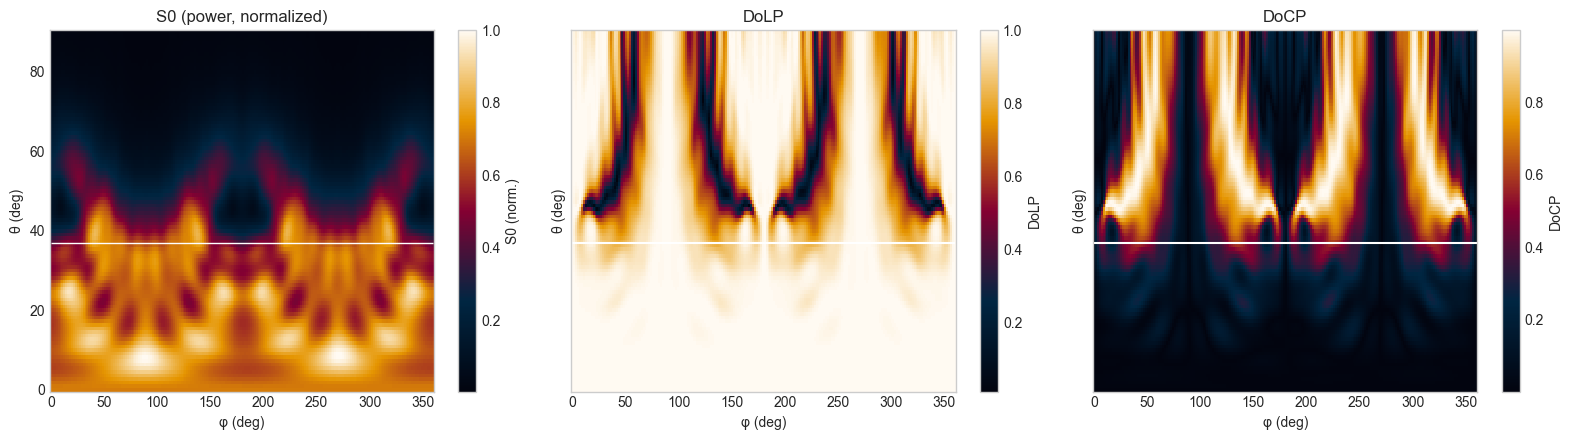

✓ Theta-phi heatmaps saved to /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/figures/polarization_heatmaps.png

📊 Creating azimuthal averages...


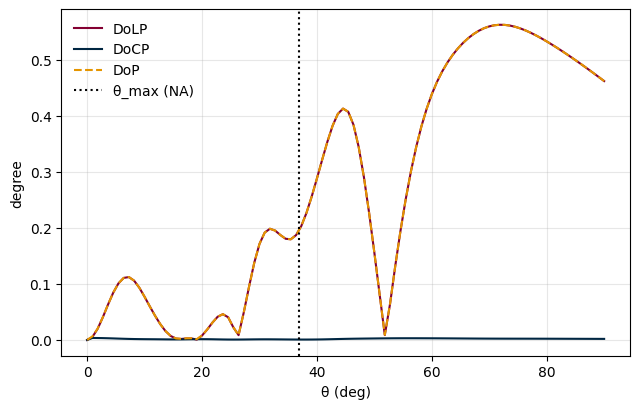

✓ Azimuthal averages saved to /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/figures/polarization_azimuthal.png

📊 Creating back focal plane plot...


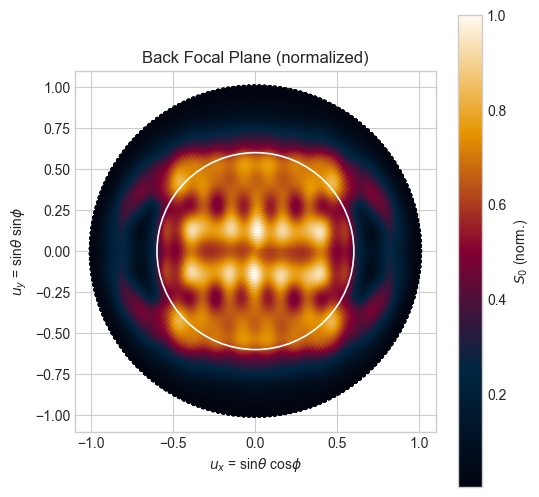

✓ Back focal plane plot saved to /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/figures/polarization_bfp.png

📊 Creating polarization quiver plot...


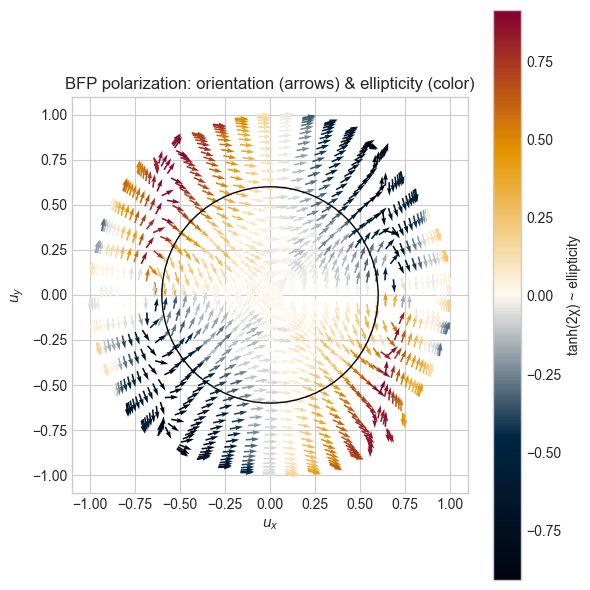

✓ Polarization quiver plot saved to /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/figures/polarization_bfp_quiver.png
✓ Polarization analysis results saved to /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/summaries/polarization_results.json
✓ Polarization analysis completed
  Degree of Linear Polarization (DoLP): 0.072
  Degree of Circular Polarization (DoCP): 0.001
  Degree of Polarization (DoP): 0.072
  Polarization angle (ψ): 0.4°
  Ellipticity angle (χ): -0.0°


In [12]:
# Polarization analysis
print("🔄 POLARIZATION ANALYSIS")
print("=" * 50)

try:
    pol_results = analyze_polarization(
        data_path=str(stage.results_path),
        wavelength_um=lockin_wavelength,
        NA=config.NA,
        n_bg=config.n_bg,
        save_results=True,
        create_plots=True,
        save_prefix="polarization",
    )
    
    print("✓ Polarization analysis completed")
    print(f"  Degree of Linear Polarization (DoLP): {pol_results.DoLP_avg:.3f}")
    print(f"  Degree of Circular Polarization (DoCP): {pol_results.DoCP_avg:.3f}")
    print(f"  Degree of Polarization (DoP): {pol_results.DoP_avg:.3f}")
    print(f"  Polarization angle (ψ): {np.degrees(pol_results.psi_avg):.1f}°")
    print(f"  Ellipticity angle (χ): {np.degrees(pol_results.chi_avg):.1f}°")
    
    # Store results for summary
    dolp = extract_float(pol_results.DoLP_avg)
    docp = extract_float(pol_results.DoCP_avg)
    dop = extract_float(pol_results.DoP_avg)
    psi_deg = extract_float(np.degrees(pol_results.psi_avg))
    chi_deg = extract_float(np.degrees(pol_results.chi_avg))
    
except Exception as exc:
    print(f"❌ Polarization analysis failed: {exc}")
    pol_results = {"error": str(exc)}
    dolp = None
    docp = None
    dop = None
    psi_deg = None
    chi_deg = None


## Step 13: Near-Field Analysis

Analyze the near-field electromagnetic field distribution to understand field confinement and mode characteristics. This corresponds to the near-field analysis part of `run_lockin_stage()`.


🔬 NEAR-FIELD ANALYSIS
🔬 NEAR-FIELD ANALYSIS
Field array shapes: Ex2=(90, 852), Ey2=(90, 852), Ez2=(90, 852), I=(90, 852)
Coordinate lengths: x=852 (Nx), y=90 (Ny)
  - X range: -6.414 to 6.414 µm
  - Y range: -1.317 to 1.317 µm
  - Max intensity: 3.01e+11
  - Total power (sum of |E|^2): 1.91e+14

📊 Field confinement analysis:
  - 1/e² width (x): 2.682 µm
  - 1/e² width (y): 0.355 µm
  - Confinement area: 0.952 µm²
  - Aspect ratio (x/y): 7.56

📐 Mode parameters:
  - dx, dy: 0.0151 µm, 0.0362 µm (dA=0.0005 µm²)
  - A_eff: 1.252 µm²
  - A_eff (λ²): 2.926
  - Effective index (calculated): 2.535

📈 Field quality metrics:
  - Field uniformity (std/mean): 5.696
  - Ex/Ey/Ez fractions: 0.338 / 0.662 / 0.000
  - Field concentration (top 10%): 0.994

📊 Creating near-field analysis plots...


[GDSTK] Unable to open GDSII file for input.
[GDSTK] Unable to open GDSII file for input.
[GDSTK] Unable to open GDSII file for input.


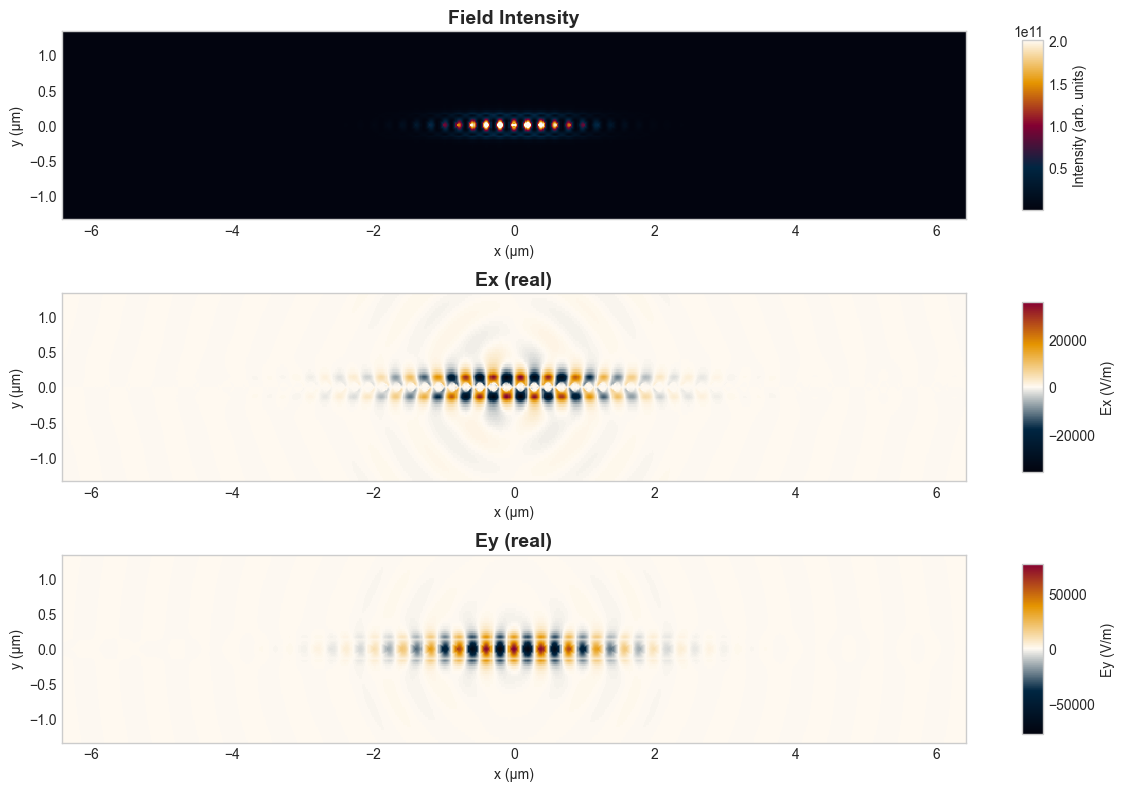

✓ Near-field analysis plots saved to '/Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/figures/nearfield_analysis.png'
✓ Near-field analysis results saved to /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/summaries/nearfield_analysis_results.json
✓ Near-field analysis completed
  Confinement area: 0.9518287068741903 µm²
  1/e² width (x): 2.6820160176770824 µm
  1/e² width (y): 0.35489299862518253 µm
  Aspect ratio (x/y): 7.557252546730776
  Mode area: 1.2515259981155396 µm²
  Mode area (λ²): 2.9261661463121156
  Effective index: 2.5348146267863303


In [13]:
# Near-field analysis
print("🔬 NEAR-FIELD ANALYSIS")
print("=" * 50)

try:
    nf_results = analyze_nearfield(
        data_path=str(stage.results_path),
        monitor_name="field_near",
        wavelength_um=lockin_wavelength,
        save_results=True,
        create_plots=True,
    )
    
    print("✓ Near-field analysis completed")
    
    # Display confinement metrics
    if "confinement" in nf_results:
        conf = nf_results["confinement"]
        print(f"  Confinement area: {conf.get('confinement_area_um2', 'N/A')} µm²")
        print(f"  1/e² width (x): {conf.get('width_x_um', 'N/A')} µm")
        print(f"  1/e² width (y): {conf.get('width_y_um', 'N/A')} µm")
        print(f"  Aspect ratio (x/y): {conf.get('aspect_ratio', 'N/A')}")
    
    # Display mode parameters
    if "mode_parameters" in nf_results:
        mode = nf_results["mode_parameters"]
        print(f"  Mode area: {mode.get('mode_area_um2', 'N/A')} µm²")
        print(f"  Mode area (λ²): {mode.get('mode_area_lambda2', 'N/A')}")
        print(f"  Effective index: {mode.get('effective_index', 'N/A')}")
    
    # Store results for summary
    nearfield_confinement_um2 = extract_float(nf_results.get("confinement", {}).get("confinement_area_um2"))
    nearfield_mode_area_um2 = extract_float(nf_results.get("mode_parameters", {}).get("mode_area_um2"))
    
except Exception as exc:
    print(f"❌ Near-field analysis failed: {exc}")
    nf_results = {"error": str(exc)}
    nearfield_confinement_um2 = None
    nearfield_mode_area_um2 = None


## Step 14: Far-Field Analysis

Analyze the far-field radiation patterns to understand how light is emitted from the cavity. This corresponds to the far-field analysis part of `run_lockin_stage()`.


🌐 FAR-FIELD ANALYSIS
🌐 FAR-FIELD ANALYSIS
✓ Found monitor: farfield_kspace
✓ Found monitor: farfield_angles

--- Analyzing farfield_kspace ---
  - Intensity range: 1.77e-08 to 3.19e-06
  - Total intensity: 1.81e-03
  - Field shape: (40, 40)

--- Analyzing farfield_angles ---
  - Directivity: 0.00
  - Beam width: 2.1°
  - Intensity range: 1.22e-08 to 3.34e-06
  - Total intensity: 2.66e-02
  - Field shape: (100, 200)

📊 Collection efficiency analysis:
  - Total power (upper hemisphere only): 1.14e-02
  - Total power (full sphere): 2.28e-02
  - Collected power: 5.67e-03
  - Collection efficiency: 0.249 (24.9%)
  - Collection angle: ±36.9°

📊 Creating far-field analysis plots...


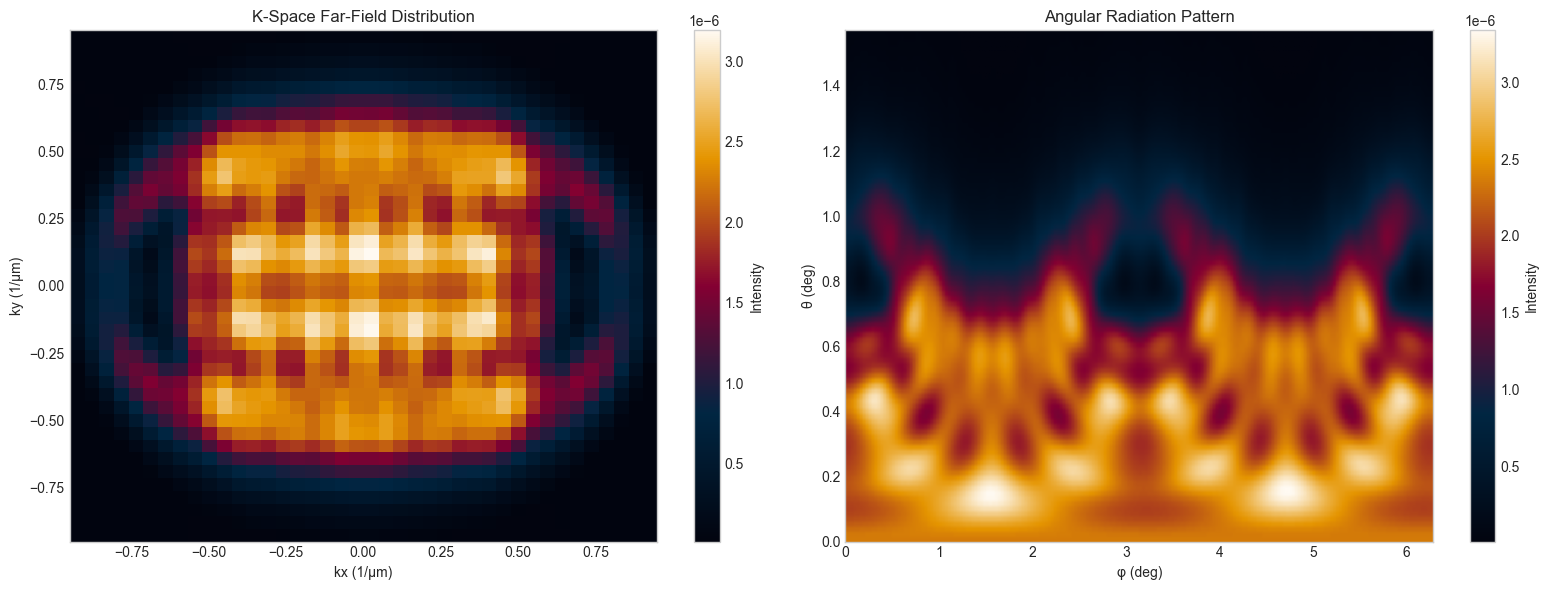


📊 Creating collection efficiency vs NA plot...


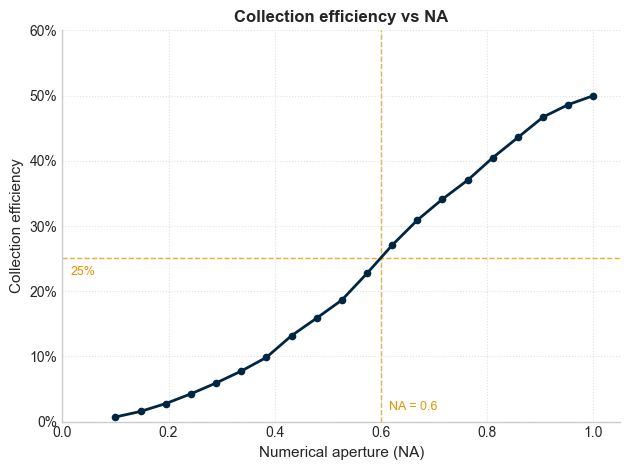

✓ Collection efficiency vs NA plot saved to '/Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/figures/collection_efficiency_vs_na.png'
✓ Far-field analysis results saved to /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/summaries/farfield_analysis_results.json
✓ Far-field analysis completed

🔍 FARFIELD_KSPACE Monitor:

🔍 FARFIELD_ANGLES Monitor:
  Directivity: 0.00
  Beam width: 2.1°

🎯 Collection Efficiency:
  Collection efficiency: 0.249 (24.9%)
  Collection angle: ±36.9°


In [14]:
# Far-field analysis
print("🌐 FAR-FIELD ANALYSIS")
print("=" * 50)

try:
    ff_results = analyze_farfield(
        data_path=str(stage.results_path),
        monitor_names=["farfield_kspace", "farfield_angles"],
        wavelength_um=lockin_wavelength,
        NA=config.NA,
        n_bg=config.n_bg,
        save_results=True,
        create_plots=True,
    )
    
    print("✓ Far-field analysis completed")
    
    # Display results for each monitor
    for monitor_name, monitor_results in ff_results.items():
        if monitor_name != 'collection_efficiency' and 'radiation_metrics' in monitor_results:
            metrics = monitor_results['radiation_metrics']
            print(f"\n🔍 {monitor_name.upper()} Monitor:")
            if 'directivity' in metrics:
                print(f"  Directivity: {metrics['directivity']:.2f}")
            if 'beam_width_deg' in metrics:
                print(f"  Beam width: {metrics['beam_width_deg']:.1f}°")
            if 'NA_effective' in metrics:
                print(f"  Effective NA: {metrics['NA_effective']:.3f}")
    
    # Display collection efficiency
    if 'collection_efficiency' in ff_results:
        ce = ff_results['collection_efficiency']
        print(f"\n🎯 Collection Efficiency:")
        print(f"  Collection efficiency: {ce['collection_efficiency']:.3f} ({ce['collection_efficiency']*100:.1f}%)")
        print(f"  Collection angle: ±{ce['theta_max_deg']:.1f}°")
    
except Exception as exc:
    print(f"❌ Far-field analysis failed: {exc}")
    ff_results = {"error": str(exc)}


## Step 15: Collection Efficiency Analysis

Perform a comprehensive analysis of collection efficiency as a function of numerical aperture. This corresponds to the collection efficiency analysis part of `run_lockin_stage()`.


In [15]:
# Collection efficiency analysis
print("📊 COLLECTION EFFICIENCY ANALYSIS")
print("=" * 50)

try:
    ce_results = analyze_collection_efficiency(
        data_path=str(stage.results_path),
        monitor_names=["farfield_kspace", "farfield_angles"],
        wavelength_um=lockin_wavelength,
        NA=config.NA,
        n_bg=config.n_bg,
        save_results=True,
        create_plots=False,  # Plots already created by far-field analysis
    )
    
    print("✓ Collection efficiency analysis completed")
    
    # Display results for each monitor
    for monitor_name, monitor_results in ce_results.items():
        if monitor_name != 'overall' and 'collection_efficiency' in monitor_results:
            eff = monitor_results['collection_efficiency']
            print(f"  {monitor_name}: {eff:.3f} ({eff*100:.1f}%)")
    
    # Display overall statistics
    if 'overall' in ce_results:
        overall = ce_results['overall']
        print(f"\n🎯 Overall Collection Efficiency Statistics:")
        print(f"  Overall efficiency: {overall['overall_efficiency']:.3f} ({overall['overall_efficiency']*100:.1f}%)")
        print(f"  Mean efficiency: {overall['mean_efficiency']:.3f} ± {overall['std_efficiency']:.3f}")
        print(f"  Range: {overall['min_efficiency']:.3f} to {overall['max_efficiency']:.3f}")
        print(f"  Number of monitors: {overall['num_monitors']}")
        
        # Store overall efficiency for summary
        collection_efficiency = extract_float(overall.get("overall_efficiency"))
    else:
        collection_efficiency = None
    
except Exception as exc:
    print(f"❌ Collection efficiency analysis failed: {exc}")
    ce_results = {"error": str(exc)}
    collection_efficiency = None


📊 COLLECTION EFFICIENCY ANALYSIS
📊 COLLECTION EFFICIENCY ANALYSIS
✓ Found monitor: farfield_kspace
✓ Found monitor: farfield_angles

--- Analyzing collection efficiency for farfield_kspace ---
  - Collection efficiency: 1.000
  - Total power (unknown): 1.81e-03
  - Total power (full sphere): 0.00e+00
  - Collected power: 1.81e-03

--- Analyzing collection efficiency for farfield_angles ---
  - Collection efficiency: 0.249
  - Total power (upper hemisphere only): 1.14e-02
  - Total power (full sphere): 2.28e-02
  - Collected power: 5.67e-03

📊 Overall collection efficiency analysis:
  - Overall collection efficiency: 0.305 (30.5%)
  - Mean efficiency: 0.625 ± 0.375
  - Range: 0.249 to 1.000
  - Total power: 2.46e-02
  - Collected power: 7.48e-03
✓ Collection efficiency results saved to /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/summaries/collection_efficiency_results.json
✓ Collection efficiency analysis completed
  farfield_kspace: 1.000 (100.0%)

## Step 16: Create Lock-in Summary and Display Results

Create the comprehensive lock-in summary and display the final workflow results. This corresponds to the summary creation and workflow completion in `run_lockin_stage()` and `run_workflow()`.


In [16]:
# Create lock-in summary
print("📋 CREATING LOCK-IN SUMMARY")
print("=" * 50)

# Create comprehensive lock-in summary
lockin_summary = {
    "stage": stage.name,
    "simulation_file": str(stage.simulation_path),
    "results_file": str(stage.results_path),
    "run_time_ps": stage.run_time_ps,
    "bandwidth_rel": stage.bandwidth_rel,
    "lockin_wavelength_um": lockin_wavelength,
    "lockin_frequency_thz": lockin_frequency_thz,
    "q_factor": q_for_lockin,
    "mode_volume_um3": mode_volume_um3,
    "purcell_factor": purcell_factor,
    "dolp": dolp,
    "docp": docp,
    "dop": dop,
    "psi_deg": psi_deg,
    "chi_deg": chi_deg,
    "nearfield_confinement_um2": nearfield_confinement_um2,
    "nearfield_mode_area_um2": nearfield_mode_area_um2,
    "collection_efficiency": collection_efficiency,
}

# Save lock-in summary
save_json(lockin_summary, stage.summary_path)
print(f"✓ Lock-in summary written to {stage.summary_path}")

# Display final workflow summary
print("\n" + "=" * 80)
print("📋 WORKFLOW SUMMARY")
print("=" * 80)

# Scout stage results
print(f"🔎 Scout Stage:")
print(f"  Resonance wavelength: {scout_summary['resonance_wavelength_um']:.6f} µm")
print(f"  Resonance frequency: {scout_summary['resonance_frequency_thz']:.6f} THz")
print(f"  Quality factor: {scout_summary['q_factor']:,.0f}")
if scout_summary.get('decay_time_ps'):
    print(f"  Decay time: {scout_summary['decay_time_ps']:.3f} ps")

# Lock-in stage results
print(f"\n🎯 Lock-in Stage:")
print(f"  Lock-in wavelength: {lockin_summary['lockin_wavelength_um']:.6f} µm")
print(f"  Lock-in frequency: {lockin_summary['lockin_frequency_thz']:.6f} THz")

if lockin_summary.get('mode_volume_um3'):
    print(f"  Mode volume: {lockin_summary['mode_volume_um3']:.3f} µm³")
if lockin_summary.get('purcell_factor'):
    print(f"  Purcell factor: {lockin_summary['purcell_factor']:.2f}")
if lockin_summary.get('collection_efficiency'):
    print(f"  Collection efficiency: {lockin_summary['collection_efficiency']*100:.1f}%")
if lockin_summary.get('dolp'):
    print(f"  Degree of linear polarization: {lockin_summary['dolp']:.3f}")
if lockin_summary.get('dop'):
    print(f"  Degree of polarization: {lockin_summary['dop']:.3f}")

print(f"\n📁 Generated Files:")
print(f"  Scout summary: {config.scout.summary_path}")
print(f"  Lock-in summary: {config.lockin.summary_path}")
print(f"  All analysis results and visualizations have been saved")

print(f"\n🏁 WORKFLOW COMPLETE")
print("=" * 80)


📋 CREATING LOCK-IN SUMMARY
✓ Lock-in summary written to /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/summaries/lockin_summary_0.19um.json

📋 WORKFLOW SUMMARY
🔎 Scout Stage:
  Resonance wavelength: 0.653989 µm
  Resonance frequency: 458.405960 THz
  Quality factor: 13,387
  Decay time: 9.296 ps

🎯 Lock-in Stage:
  Lock-in wavelength: 0.653989 µm
  Lock-in frequency: 458.405960 THz
  Collection efficiency: 30.5%
  Degree of linear polarization: 0.072
  Degree of polarization: 0.072

📁 Generated Files:
  Scout summary: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/summaries/scout_summary_0.19um.json
  Lock-in summary: /Users/sandrobuzzi/Documents/MIT/QPAIG/Projects/Silicon Hard Mask/Simulations/data/summaries/lockin_summary_0.19um.json
  All analysis results and visualizations have been saved

🏁 WORKFLOW COMPLETE
